# VSE Quantitative Analysis

**Goal:** Vascular Super-Enhancement (VSE) increases contrast between vasculature
and surrounding tissue without degrading image quality.

This notebook evaluates two claims:
1. **CNR is improved** — VSE increases contrast-to-noise ratio between vessels (Ao, IVS, PA) and background tissue.
2. **SNR is preserved** — VSE does not degrade signal-to-noise ratio in any region.

In [161]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"

# ── Global plot theme (edit this cell to restyle all figures) ──
COLORS = {"normal": "#5B8EC9", "vse": "#E8855E"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    """Apply face colors to box plot patches."""
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

LEGEND_HANDLES = [
    Patch(facecolor=COLORS["normal"], edgecolor="#333", alpha=0.85, label="Normal"),
    Patch(facecolor=COLORS["vse"], edgecolor="#333", alpha=0.85, label="VSE"),
]

data = pd.read_csv(CSV_PATH)
print(f"{len(data)} rows  |  {data['patient'].nunique()} patients  |  "
      f"{sorted(data['region'].unique())}  |  {sorted(data['reconstruction'].unique())}")
data.head()

2680 rows  |  17 patients  |  ['Ao', 'Background', 'IVS', 'PA']  |  ['normal', 'vse']


,patient,region,reconstruction,timepoint,mean,std,snr
0,Balboloop,Ao,normal,1,1452.38,67.66,21.465859
1,Balboloop,Ao,normal,2,1399.85,80.98,17.286367
2,Balboloop,Ao,normal,3,1329.10,85.26,15.588787
3,Balboloop,Ao,normal,4,1279.85,55.08,23.236202
4,Balboloop,Ao,normal,5,1234.62,34.42,35.869262


## Data cleaning

Drop timepoints with anomalous SNR (> 100). The 99.5th percentile of SNR across
the dataset is ~54; all 6 values above 100 come from Golotag/PA/vse timepoints 4–9
where the viewer reported near-zero std (confirmed on re-inspection — likely the ROI
overlapping a very homogeneous patch during those cardiac phases).

In [162]:
SNR_OUTLIER_THRESHOLD = 100

outlier_mask = data["snr"] > SNR_OUTLIER_THRESHOLD
n_dropped = outlier_mask.sum()

if n_dropped:
    print(f"Dropping {n_dropped} timepoints with SNR > {SNR_OUTLIER_THRESHOLD}:")
    print(data[outlier_mask][["patient", "region", "reconstruction", "timepoint", "std", "snr"]].to_string(index=False))
else:
    print("No SNR outliers detected.")

data = data[~outlier_mask].reset_index(drop=True)
print(f"\n{len(data)} rows remaining")

Dropping 6 timepoints with SNR > 100:
patient region reconstruction  timepoint   std          snr
Golotag     PA            vse          4 13.00   602.797692
Golotag     PA            vse          5  0.45 17497.600000
Golotag     PA            vse          6 31.99   247.660519
Golotag     PA            vse          7 55.00   143.376545
Golotag     PA            vse          8 34.83   222.321849
Golotag     PA            vse          9 41.59   187.152200

2674 rows remaining


## Derived metrics

Compute time-averaged SNR and CNR for downstream analyses.

In [163]:
regions = sorted(data["region"].unique())
vessel_regions = [r for r in regions if r != "Background"]
cnr_regions = ["Ao", "PA"]  # CNR only meaningful for vascular lumen, not IVS

# --- Time-averaged SNR per (patient, region, reconstruction) ---
snr_avg = (
    data.groupby(["patient", "region", "reconstruction"])["snr"]
    .mean()
    .reset_index()
    .rename(columns={"snr": "snr_mean"})
)

snr_pivot = snr_avg.pivot_table(
    index=["patient", "region"],
    columns="reconstruction",
    values="snr_mean",
)
snr_pivot["vse_minus_normal"] = snr_pivot["vse"] - snr_pivot["normal"]
snr_pivot["vse_over_normal"] = snr_pivot["vse"] / snr_pivot["normal"]

# --- CNR (vessel vs Background): (mean_vessel - mean_bg) / std_bg ---
bg = data[data["region"] == "Background"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "bg_mean", "std": "bg_std"}
)
vessels = data[data["region"].isin(cnr_regions)].copy()
cnr_bg_data = vessels.merge(bg, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_bg_data["cnr"] = (cnr_bg_data["mean"] - cnr_bg_data["bg_mean"]) / cnr_bg_data["bg_std"]

cnr_bg_avg = (
    cnr_bg_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_bg_pivot = cnr_bg_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_bg_pivot["vse_minus_normal"] = cnr_bg_pivot["vse"] - cnr_bg_pivot["normal"]
cnr_bg_pivot["vse_over_normal"] = cnr_bg_pivot["vse"] / cnr_bg_pivot["normal"]

# --- CNR (vessel vs IVS): (mean_vessel - mean_IVS) / std_bg ---
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean"]].rename(
    columns={"mean": "ivs_mean"}
)
cnr_ivs_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_ivs_data = cnr_ivs_data.merge(bg, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_ivs_data["cnr"] = (cnr_ivs_data["mean"] - cnr_ivs_data["ivs_mean"]) / cnr_ivs_data["bg_std"]

cnr_ivs_avg = (
    cnr_ivs_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_ivs_pivot = cnr_ivs_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_ivs_pivot["vse_minus_normal"] = cnr_ivs_pivot["vse"] - cnr_ivs_pivot["normal"]
cnr_ivs_pivot["vse_over_normal"] = cnr_ivs_pivot["vse"] / cnr_ivs_pivot["normal"]

# Aliases used by downstream plots (switch these to change which CNR is primary)
cnr_data, cnr_avg, cnr_pivot = cnr_bg_data, cnr_bg_avg, cnr_bg_pivot

# --- Time-averaged mean SI ---
si_avg = (
    data.groupby(["patient", "region", "reconstruction"])["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "si_mean"})
)

print(f"SNR: {len(snr_avg)} entries  |  CNR_bg: {len(cnr_bg_avg)}, CNR_ivs: {len(cnr_ivs_avg)} entries  |  SI: {len(si_avg)} entries")

SNR: 134 entries  |  CNR_bg: 66, CNR_ivs: 66 entries  |  SI: 134 entries


---

# 1. Primary result: VSE improves vascular contrast (CNR)

Two CNR definitions are compared:
- **CNR_bg** = (mean_vessel − mean_background) / std_background
- **CNR_ivs** = (mean_vessel − mean_IVS) / std_background

CNR_ivs is the more clinically relevant metric — it measures contrast between the
blood pool and adjacent myocardium (IVS), normalized by image noise.

### 1a. CNR distribution: Normal vs. VSE (both definitions)

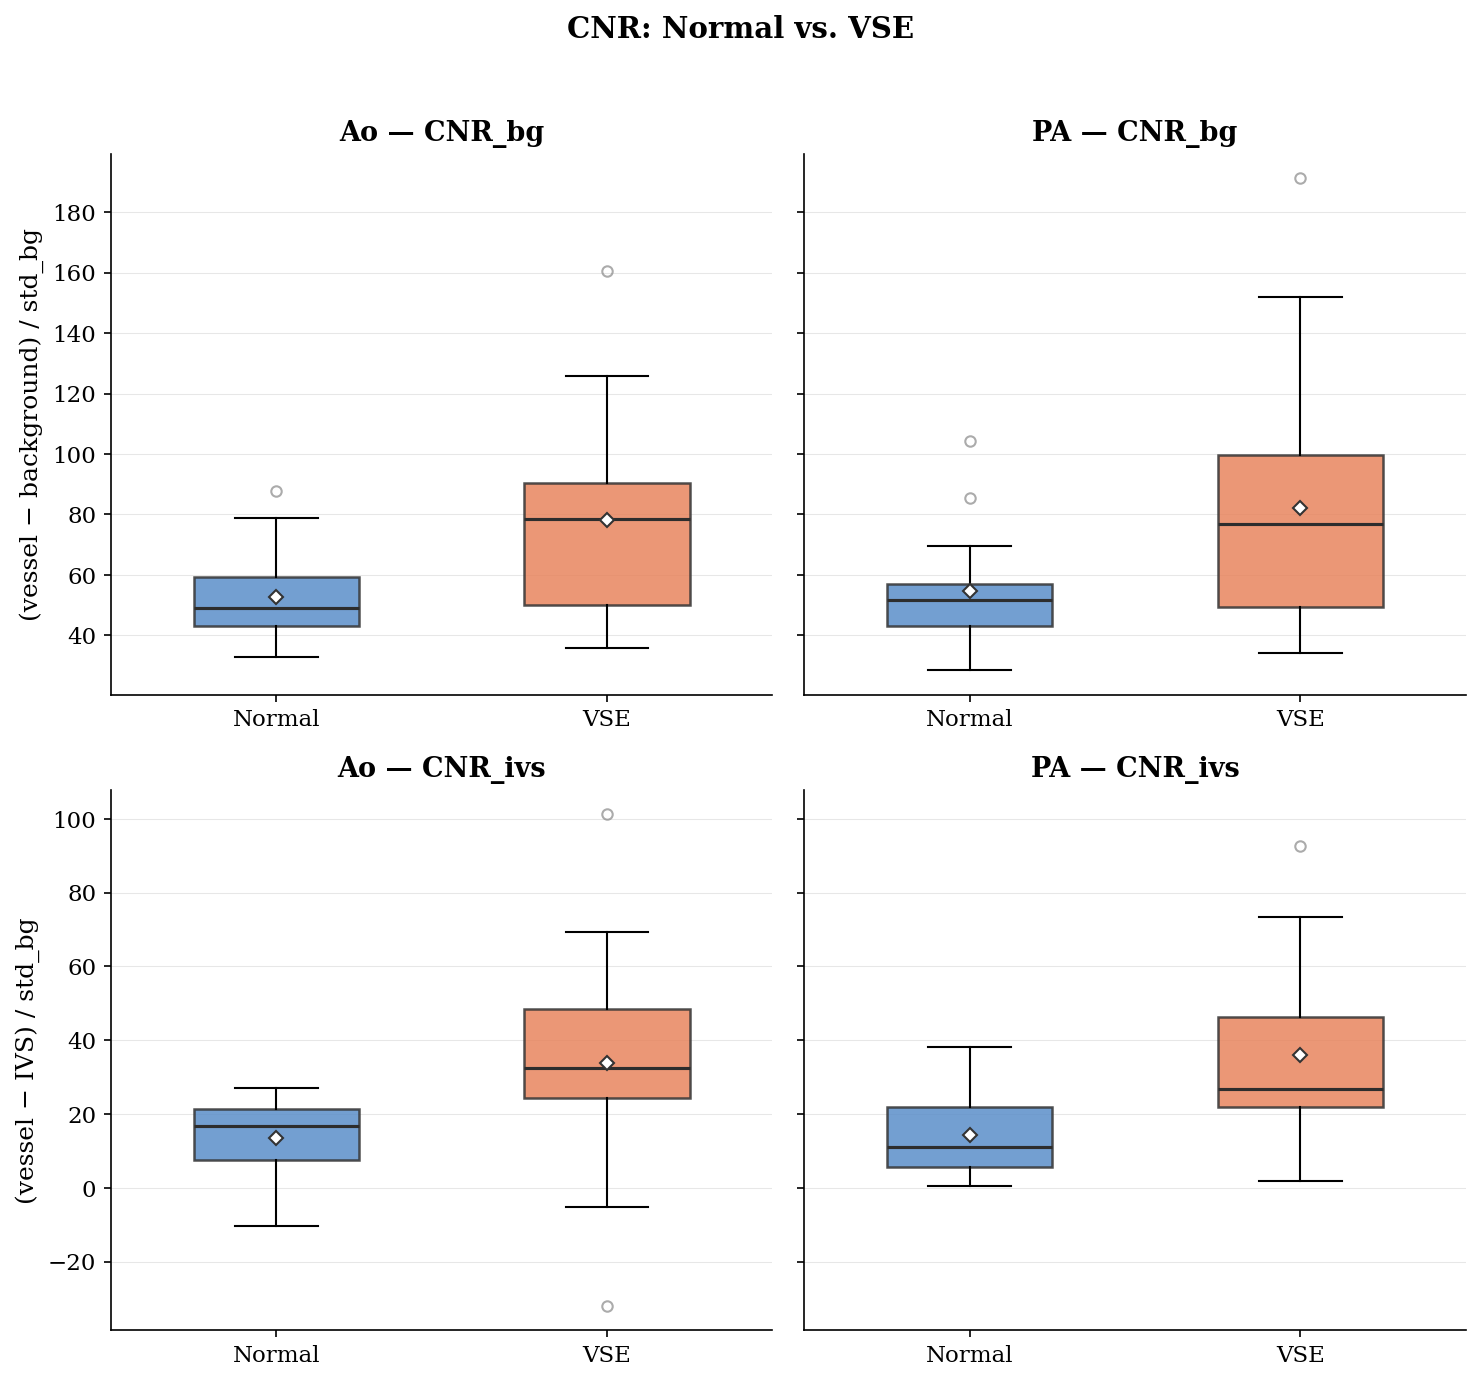

In [164]:
fig, axes = plt.subplots(2, len(cnr_regions), figsize=(5 * len(cnr_regions), 9), sharey="row")

for j, region in enumerate(cnr_regions):
    for i, (avg_df, label) in enumerate([(cnr_bg_avg, "CNR_bg"), (cnr_ivs_avg, "CNR_ivs")]):
        ax = axes[i, j]
        subset = avg_df[avg_df["region"] == region]
        normal = subset[subset["reconstruction"] == "normal"]["cnr_mean"]
        vse = subset[subset["reconstruction"] == "vse"]["cnr_mean"]

        bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Normal", "VSE"])
        ax.set_title(f"{region} — {label}", fontweight="bold")

    axes[0, 0].set_ylabel("(vessel − background) / std_bg")
    axes[1, 0].set_ylabel("(vessel − IVS) / std_bg")

fig.suptitle("CNR: Normal vs. VSE", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1a (alt). CNR and SNR side by side

CNR_bg and CNR_ivs each shown with SNR for context.

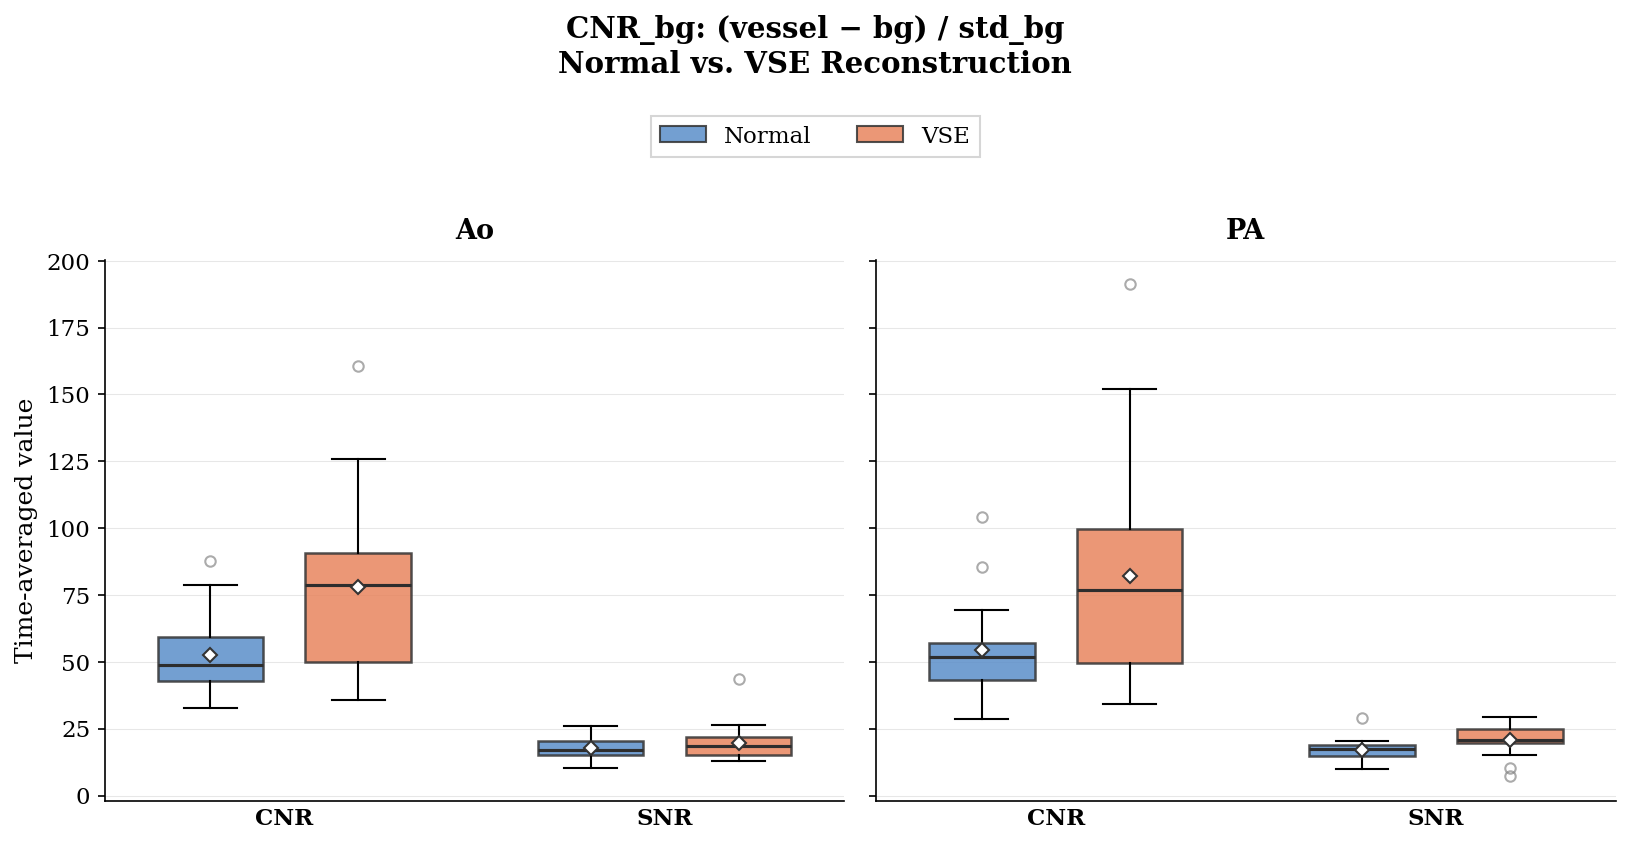

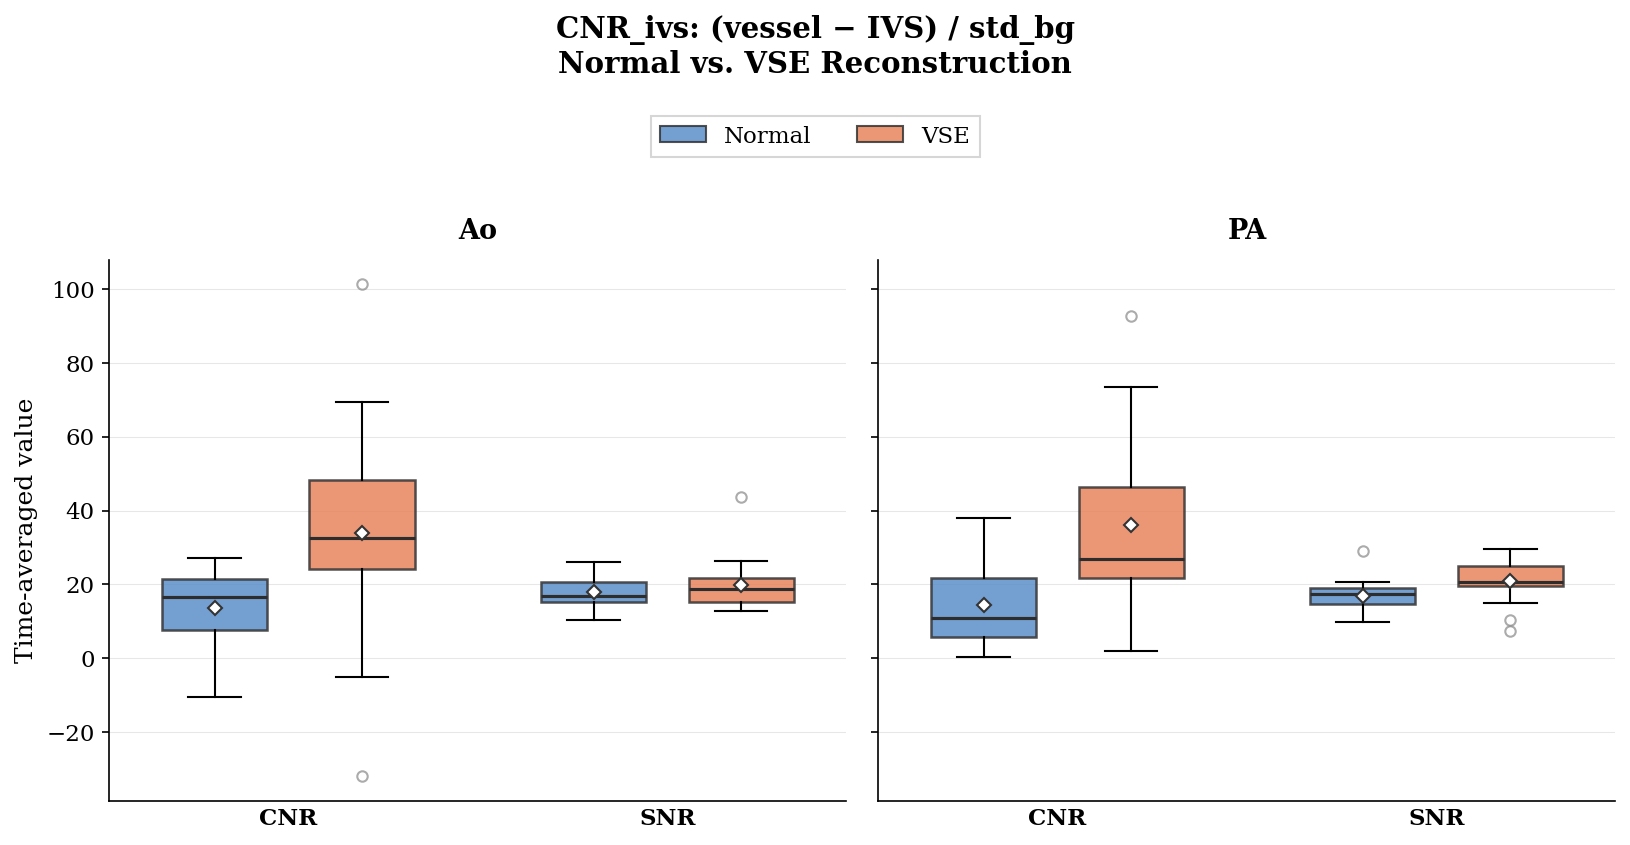

In [165]:
def _get_nv(df, region, col):
    """Return (normal_values, vse_values) for a region."""
    sub = df[df["region"] == region]
    return (sub[sub["reconstruction"] == "normal"][col],
            sub[sub["reconstruction"] == "vse"][col])

for cnr_label, cnr_avg_df in [("CNR_bg: (vessel − bg) / std_bg", cnr_bg_avg),
                               ("CNR_ivs: (vessel − IVS) / std_bg", cnr_ivs_avg)]:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5), sharey=True)

    for ax, region in zip(axes, cnr_regions):
        cnr_n, cnr_v = _get_nv(cnr_avg_df, region, "cnr_mean")
        snr_n, snr_v = _get_nv(snr_avg, region, "snr_mean")

        bp = ax.boxplot(
            [cnr_n, cnr_v, snr_n, snr_v],
            positions=[0, 0.7, 1.8, 2.5],
            widths=0.5,
            **BOXPLOT_KW,
        )
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]] * 2)

        ax.set_xticks([0.35, 2.15])
        ax.set_xticklabels(["CNR", "SNR"], fontweight="bold")
        ax.set_title(region, fontweight="bold", pad=10)
        ax.tick_params(axis="x", length=0)

    axes[0].set_ylabel("Time-averaged value")
    fig.legend(handles=LEGEND_HANDLES, loc="upper center", ncol=2,
               frameon=True, fancybox=False, edgecolor="#ccc",
               fontsize=11, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"{cnr_label}\nNormal vs. VSE Reconstruction",
                 fontsize=14, fontweight="bold", y=1.12)
    fig.tight_layout()
    plt.show()

### 1b. Paired patient-level CNR: Normal → VSE

Each line connects one patient's time-averaged CNR under Normal (left) to VSE (right).
Green = VSE improved CNR; red = VSE reduced CNR. Both CNR definitions shown.

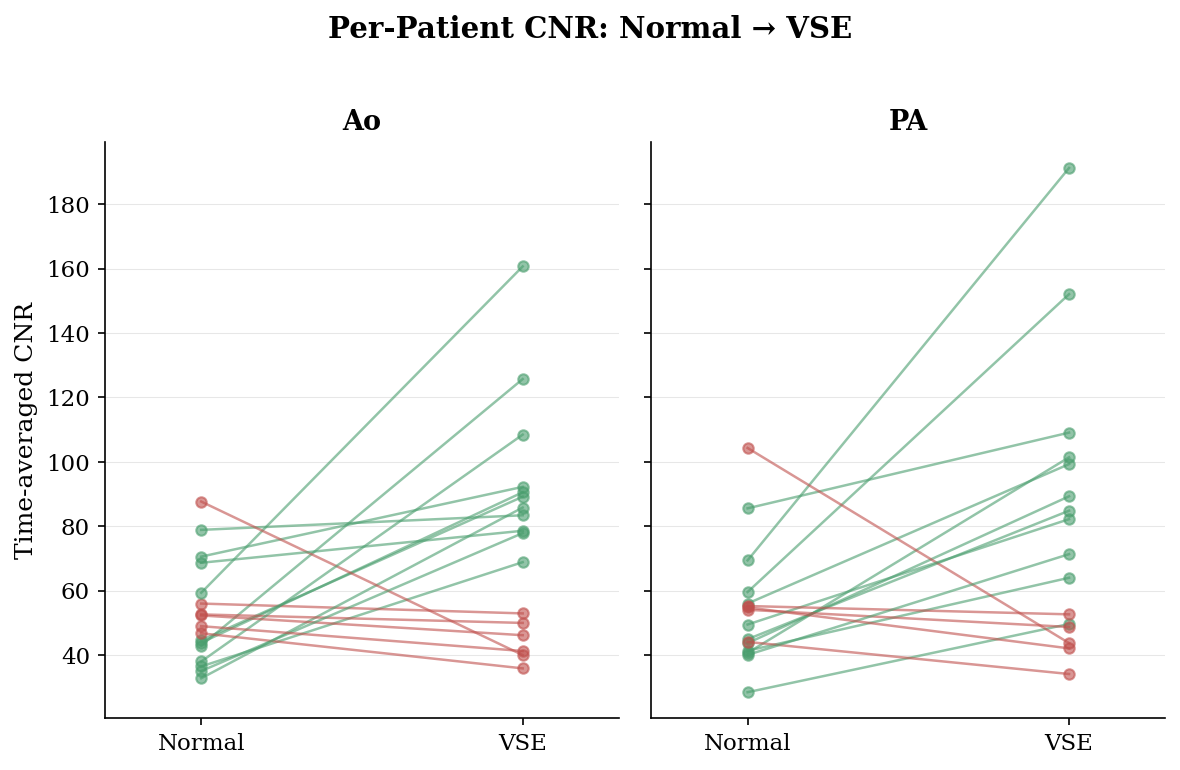

In [166]:
SLOPE_UP = "#4a9e6e"
SLOPE_DOWN = "#c0504d"

for cnr_label, pivot_df in [("CNR_bg (vessel − background)", cnr_bg_pivot),
                             ("CNR_ivs (vessel − IVS)", cnr_ivs_pivot)]:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 5), sharey=True)

    for ax, region in zip(axes, cnr_regions):
        pivot = pivot_df.reset_index()
        sub = pivot[pivot["region"] == region].dropna(subset=["normal", "vse"])

        for _, row in sub.iterrows():
            color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
            ax.plot([0, 1], [row["normal"], row["vse"]], marker="o", color=color,
                    alpha=0.6, linewidth=1.2, markersize=5)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Normal", "VSE"])
        ax.set_title(region, fontweight="bold")
        ax.set_xlim(-0.3, 1.3)

    axes[0].set_ylabel("Time-averaged CNR")
    fig.suptitle(f"Per-Patient {cnr_label}: Normal → VSE",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

### 1c. CNR summary statistics

In [167]:
cnr_summary = (
    cnr_avg.groupby(["region", "reconstruction"])["cnr_mean"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(2)
)
print("Time-averaged CNR summary (across patients):")
display(cnr_summary)

cnr_ratio_by_region = (
    cnr_pivot.reset_index()
    .groupby("region")["vse_over_normal"]
    .agg(["mean", "std"])
    .round(3)
    .rename(columns={"mean": "ratio_mean", "std": "ratio_std"})
)
print("\nVSE/Normal CNR ratio (averaged across patients):")
display(cnr_ratio_by_region)

Time-averaged CNR summary (across patients):


mean    std    min     max  count
region reconstruction                                    
Ao     normal          52.68  15.83  32.79   87.66     17
       vse             78.09  33.25  35.87  160.66     17
PA     normal          54.48  18.77  28.47  104.30     16
       vse             82.23  42.51  34.13  191.23     16


VSE/Normal CNR ratio (averaged across patients):


,ratio_mean,ratio_std
region,,
Ao,1.625,0.827
PA,1.583,0.692


### 1d. VSE / Normal CNR ratio heatmap

Rows = patients, columns = vessel regions. Color encodes the VSE/Normal
time-averaged CNR ratio (diverging around 1.0: blue = VSE lower, red = VSE higher).

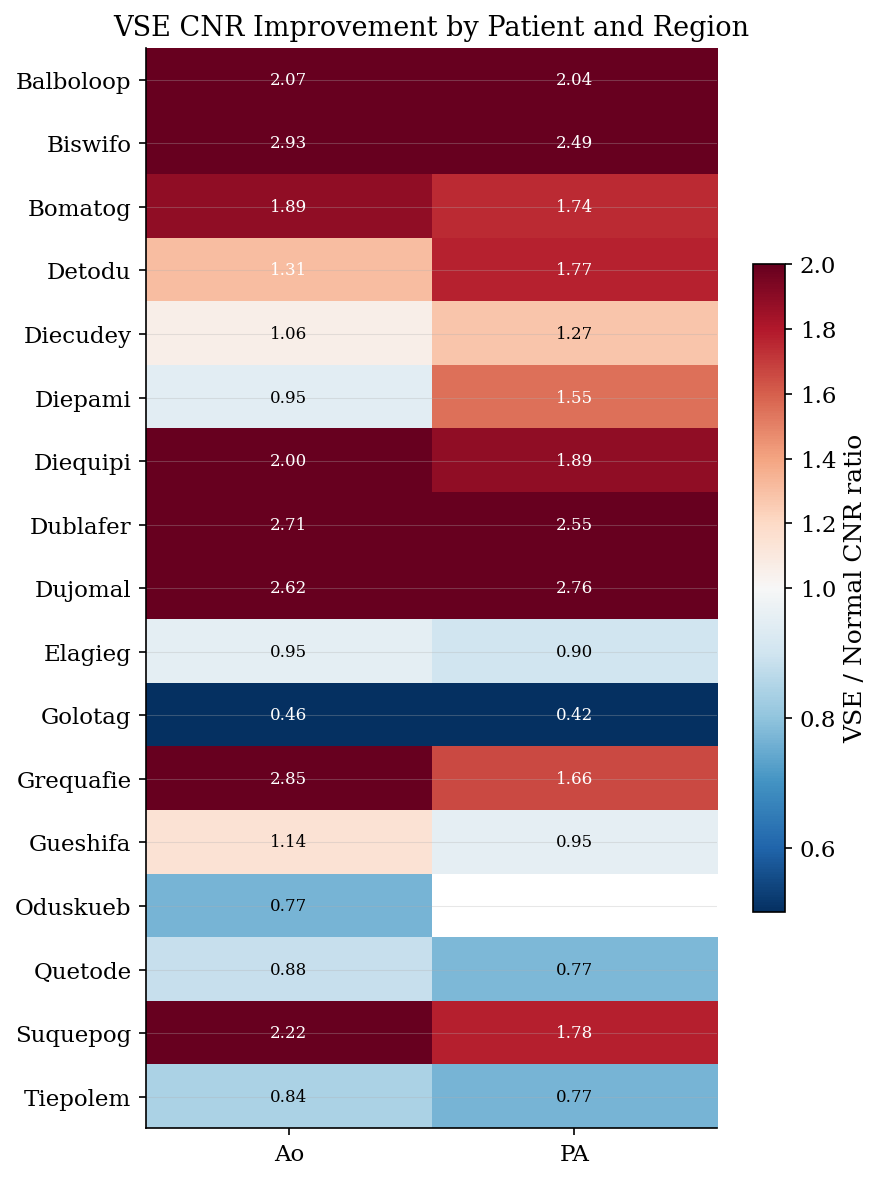

In [168]:
cnr_heatmap_data = (
    cnr_pivot.reset_index()
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = cnr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(cnr_heatmap_data.columns)))
ax.set_xticklabels(cnr_heatmap_data.columns)
ax.set_yticks(range(len(cnr_heatmap_data.index)))
ax.set_yticklabels(cnr_heatmap_data.index)

for i in range(len(cnr_heatmap_data.index)):
    for j in range(len(cnr_heatmap_data.columns)):
        val = cnr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="VSE / Normal CNR ratio")
ax.set_title("VSE CNR Improvement by Patient and Region", fontsize=13)
fig.tight_layout()
plt.show()

---

# 2. Quality check: VSE preserves SNR

VSE is not expected to increase SNR — the goal is to confirm that applying VSE
does not degrade signal-to-noise ratio relative to normal reconstruction.

### 2a. SNR distribution: Normal vs. VSE by region

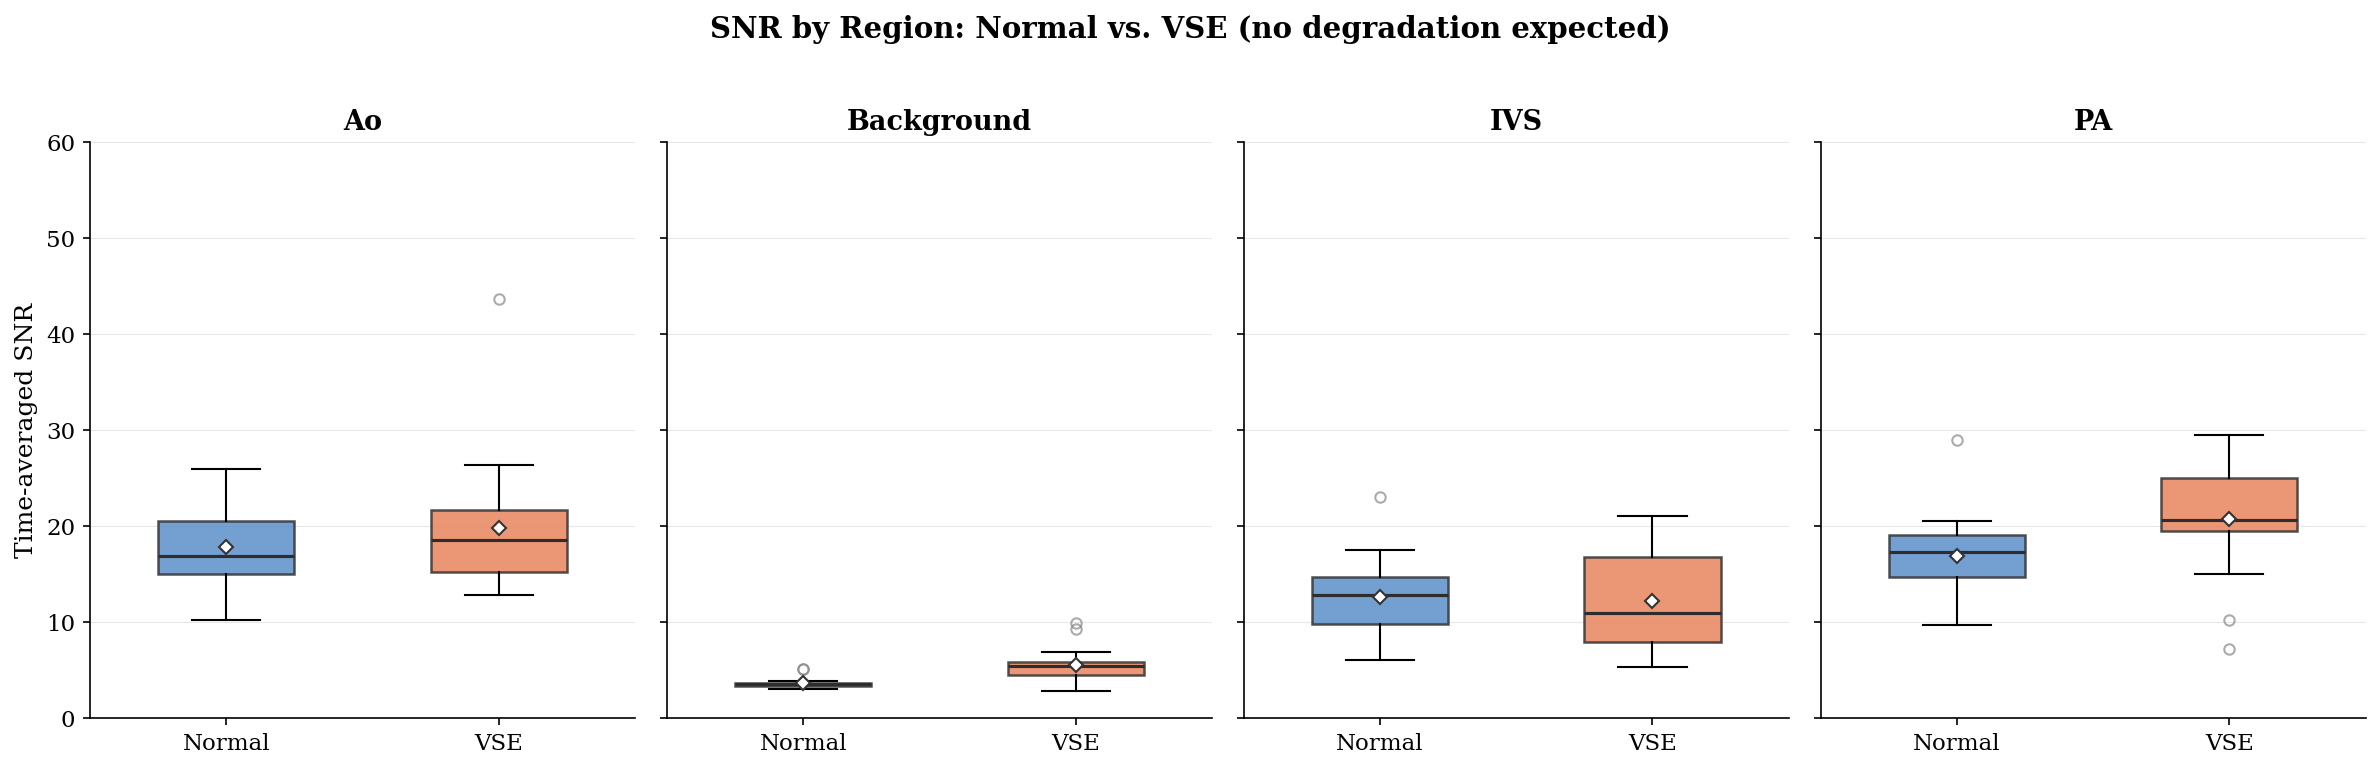

In [169]:
SNR_YLIM = (0, 60)

fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 5), sharey=True)

for ax, region in zip(axes, regions):
    subset = snr_avg[snr_avg["region"] == region]
    normal = subset[subset["reconstruction"] == "normal"]["snr_mean"]
    vse = subset[subset["reconstruction"] == "vse"]["snr_mean"]

    bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
    color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "VSE"])
    ax.set_title(region, fontweight="bold")
    ax.set_ylim(SNR_YLIM)

    n_clipped = int((normal > SNR_YLIM[1]).sum() + (vse > SNR_YLIM[1]).sum())
    if n_clipped:
        ax.text(0.95, 0.95, f"{n_clipped} pts clipped",
                transform=ax.transAxes, ha="right", va="top", fontsize=8, color="gray")

axes[0].set_ylabel("Time-averaged SNR")
fig.suptitle("SNR by Region: Normal vs. VSE (no degradation expected)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 2b. Paired patient-level SNR: Normal → VSE

Each line connects one patient's time-averaged SNR under Normal (left) to VSE (right).
Near-horizontal lines indicate SNR is preserved.

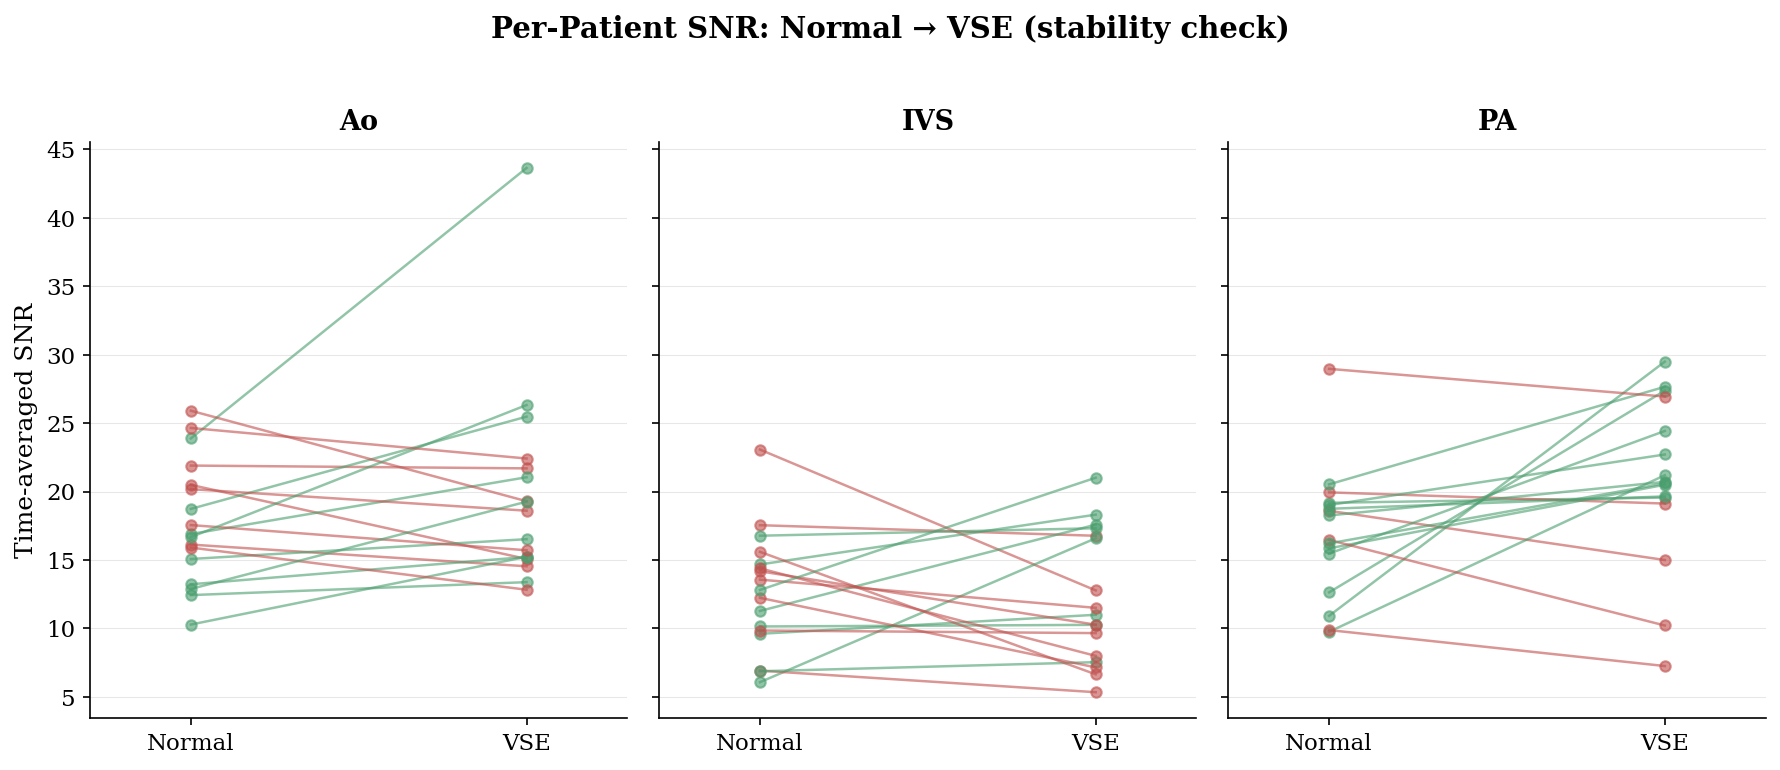

In [170]:
fig, axes = plt.subplots(1, len(vessel_regions), figsize=(4 * len(vessel_regions), 5), sharey=True)

for ax, region in zip(axes, vessel_regions):
    pivot = snr_pivot.reset_index()
    sub = pivot[pivot["region"] == region].dropna(subset=["normal", "vse"])

    for _, row in sub.iterrows():
        color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
        ax.plot([0, 1], [row["normal"], row["vse"]], marker="o", color=color,
                alpha=0.6, linewidth=1.2, markersize=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "VSE"])
    ax.set_title(region, fontweight="bold")
    ax.set_xlim(-0.3, 1.3)

axes[0].set_ylabel("Time-averaged SNR")
fig.suptitle("Per-Patient SNR: Normal → VSE (stability check)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 2c. SNR summary statistics & VSE/Normal ratio

In [171]:
snr_summary = (
    snr_avg.groupby(["region", "reconstruction"])["snr_mean"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(2)
)
print("Time-averaged SNR summary (across patients):")
display(snr_summary)

snr_ratio_by_region = (
    snr_pivot.reset_index()
    .groupby("region")["vse_over_normal"]
    .agg(["mean", "std"])
    .round(3)
    .rename(columns={"mean": "ratio_mean", "std": "ratio_std"})
)
print("\nVSE/Normal SNR ratio (≈1.0 indicates preservation):")
display(snr_ratio_by_region)

Time-averaged SNR summary (across patients):


mean   std    min    max  count
region     reconstruction                                  
Ao         normal          17.81  4.52  10.28  25.91     17
           vse             19.78  7.36  12.83  43.65     17
Background normal           3.68  0.61   3.04   5.18     17
           vse              5.54  1.88   2.86   9.96     17
IVS        normal          12.68  4.36   6.07  23.07     17
           vse             12.22  4.81   5.34  21.01     17
PA         normal          16.90  4.79   9.76  28.97     16
           vse             20.78  6.09   7.25  29.50     16


VSE/Normal SNR ratio (≈1.0 indicates preservation):


,ratio_mean,ratio_std
region,,
Ao,1.130,0.320
Background,1.549,0.593
IVS,1.051,0.549
PA,1.311,0.578


---

# 3. Supporting analyses

### 3a. Time curves over the cardiac cycle

Mean SI, SNR, and CNR over the 20 cardiac timepoints, Normal vs. VSE, averaged
across patients with ±1 SEM shading. All subplots within each metric share the
same y-axis scale for direct comparison across regions.

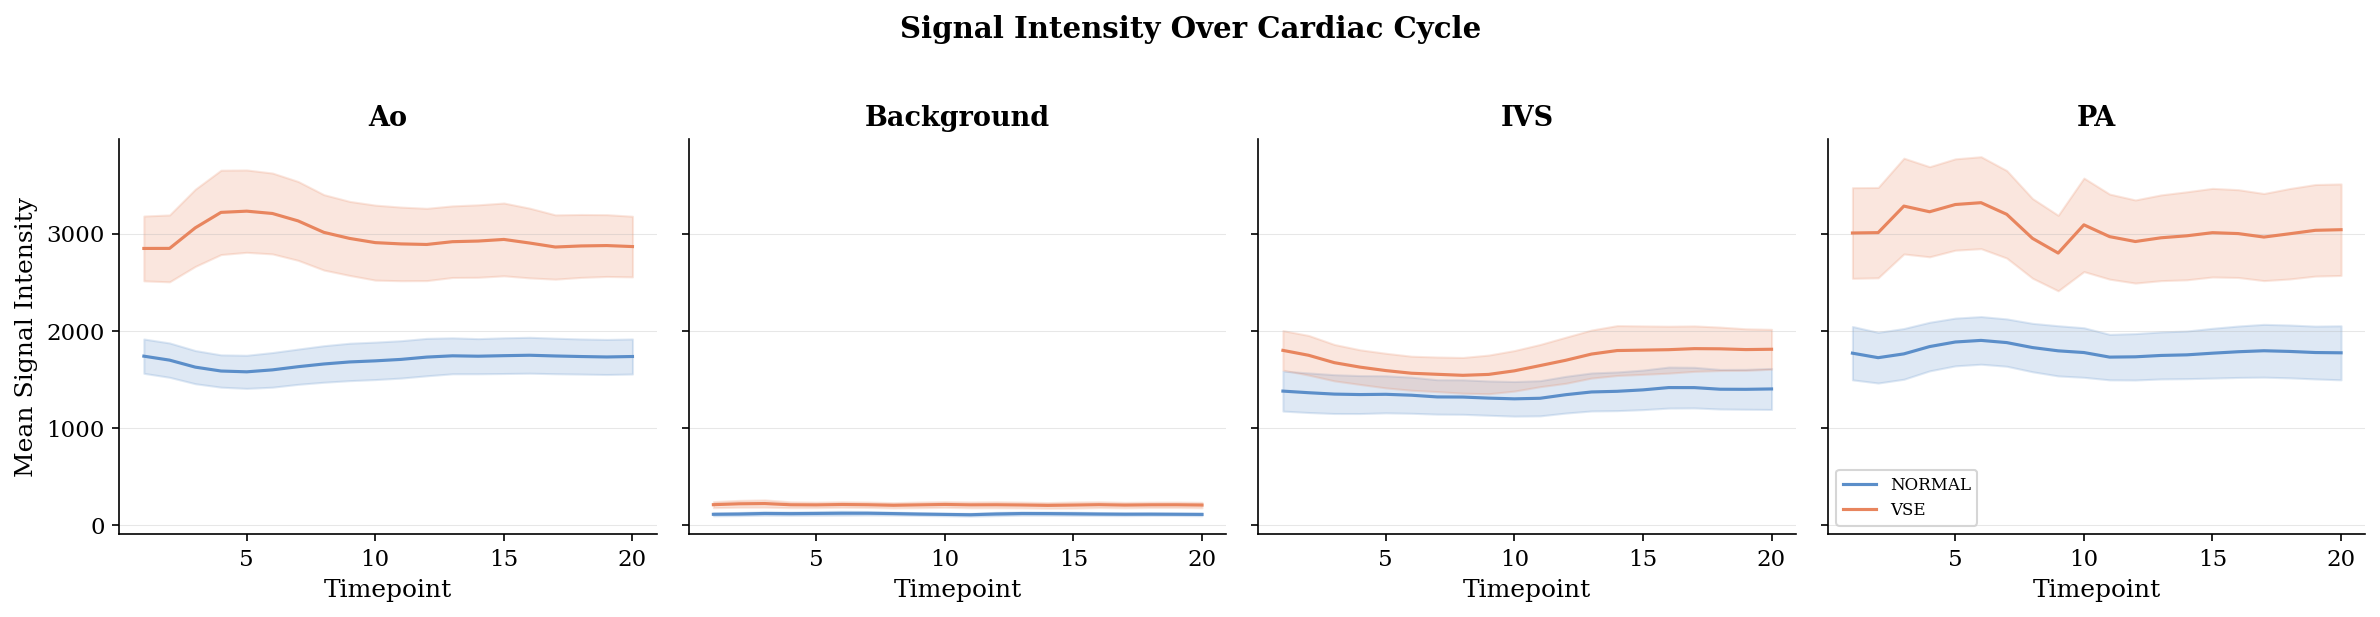

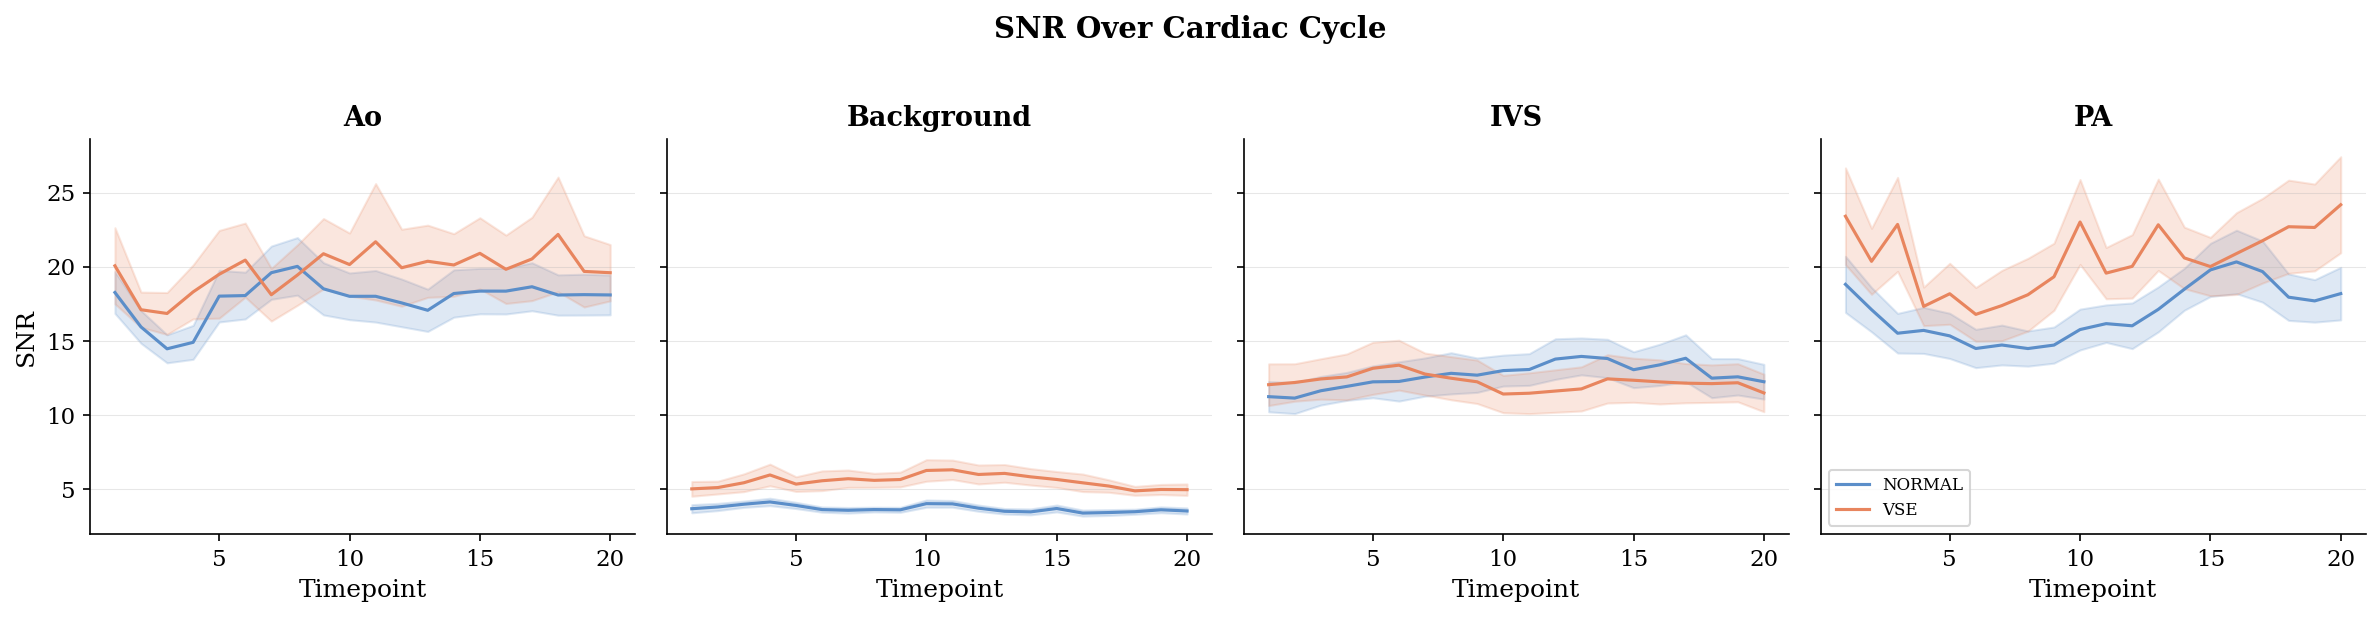

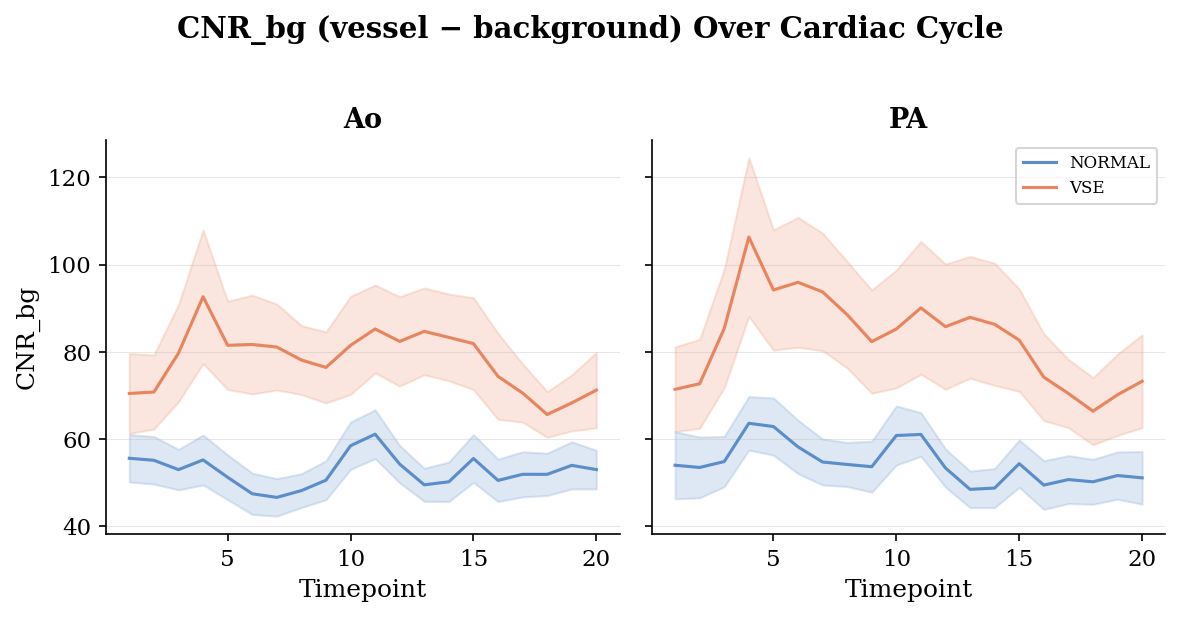

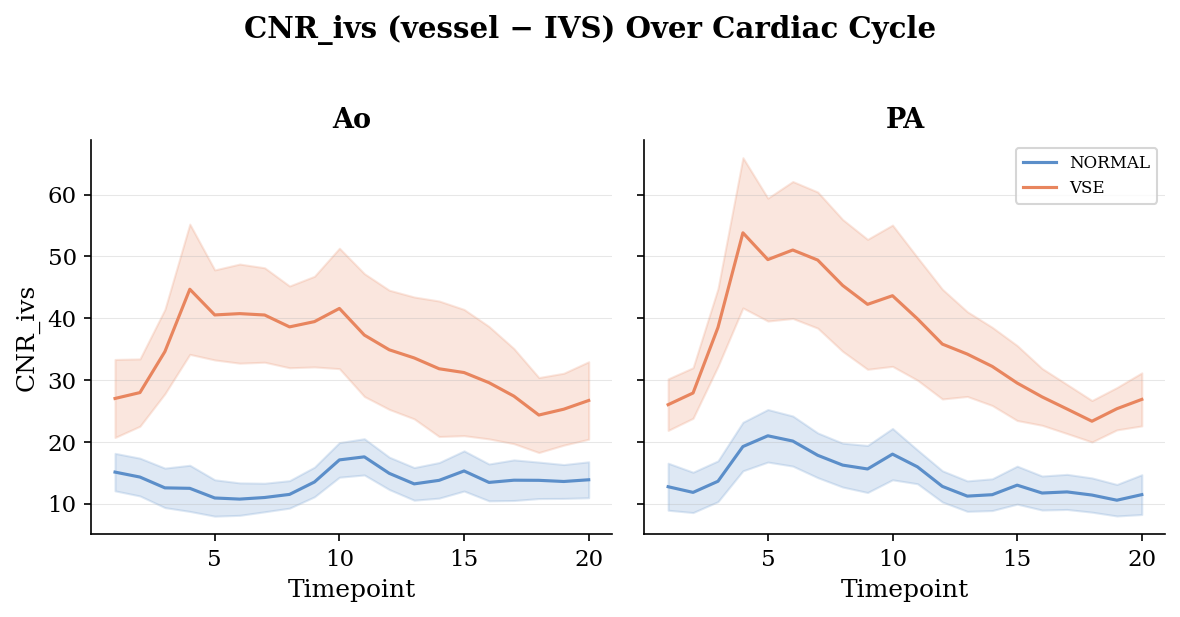

In [172]:
def _time_curve(ax, sub_data, value_col):
    """Plot Normal vs VSE time curves with SEM shading on the given axes."""
    for recon, color in COLORS.items():
        sub = sub_data[sub_data["reconstruction"] == recon]
        grouped = sub.groupby("timepoint")[value_col]
        mu = grouped.mean()
        sem = grouped.std() / np.sqrt(grouped.count())
        ax.plot(mu.index, mu.values, color=color, label=recon.upper(), linewidth=1.5)
        ax.fill_between(mu.index, mu.values - sem.values, mu.values + sem.values,
                        color=color, alpha=0.2)

# --- Signal Intensity ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "mean")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("Mean Signal Intensity")
axes[-1].legend(fontsize=8)
fig.suptitle("Signal Intensity Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- SNR ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "snr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("SNR")
axes[-1].legend(fontsize=8)
fig.suptitle("SNR Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_bg (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_bg_data[cnr_bg_data["region"] == region], "cnr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_bg")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_bg (vessel − background) Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_ivs (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_ivs_data[cnr_ivs_data["region"] == region], "cnr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_ivs")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_ivs (vessel − IVS) Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3b. Grouped summary bar plots

Mean SI, SNR, and CNR grouped by region with Normal vs. VSE bars and SEM error bars.

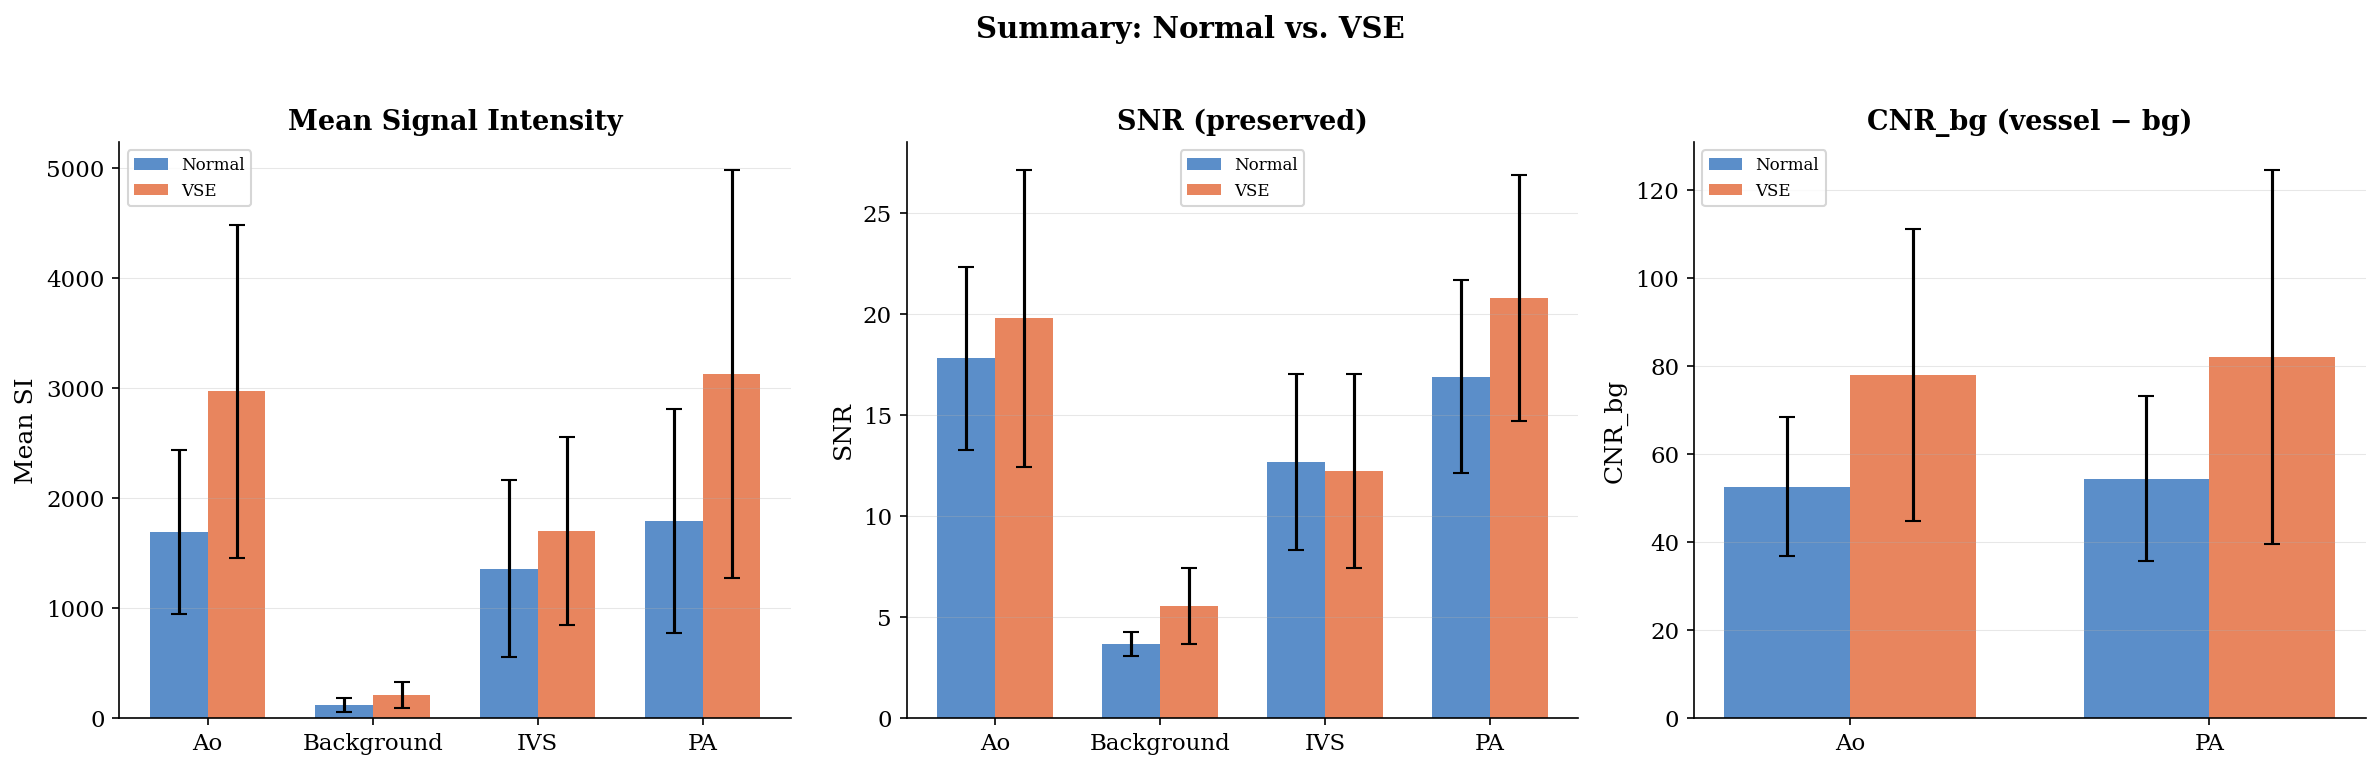

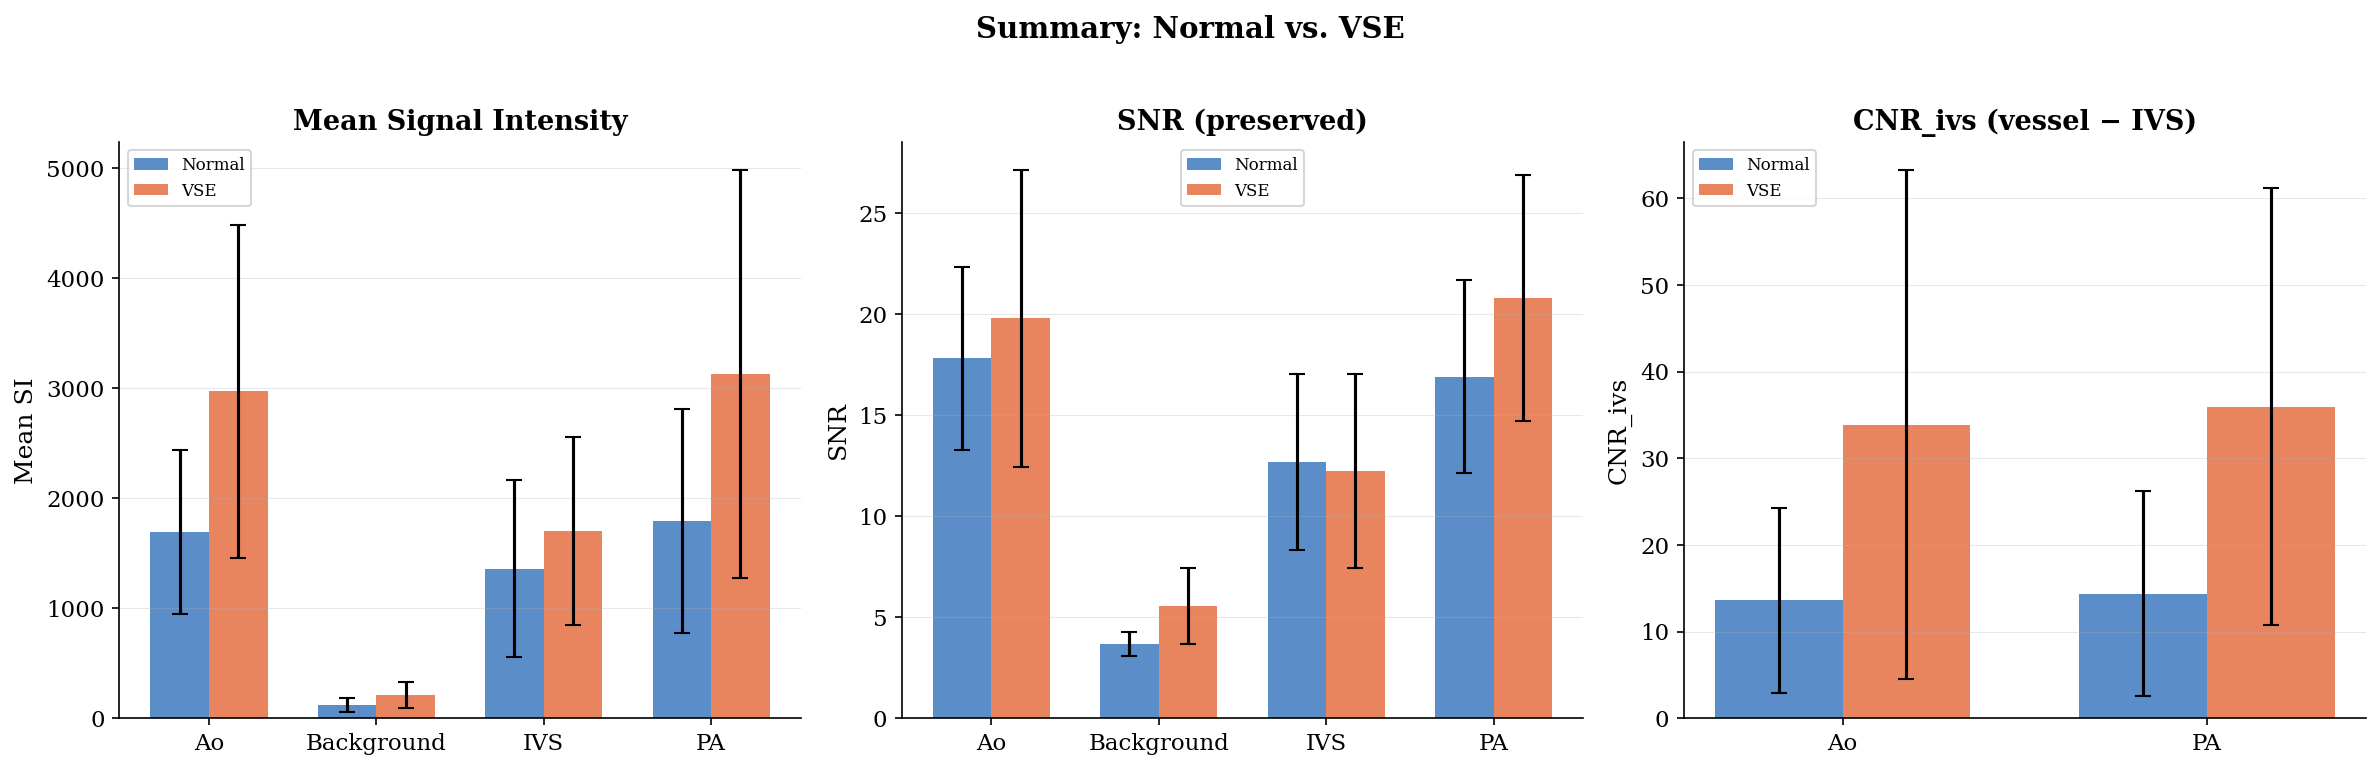

In [173]:
def _bar_data(df, value_col, region_list):
    """Return (means_normal, sds_normal, means_vse, sds_vse) for each region."""
    mn, sn, mv, sv = [], [], [], []
    for region in region_list:
        for recon, m_list, s_list in [("normal", mn, sn), ("vse", mv, sv)]:
            vals = df[(df["region"] == region) & (df["reconstruction"] == recon)][value_col]
            m_list.append(vals.mean())
            s_list.append(vals.std())
    return mn, sn, mv, sv

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_width = 0.35

# Mean SI (all regions)
ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
x = np.arange(len(regions))
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

# SNR (all regions) — expect similar heights
ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

# CNR_bg (Ao + PA only)
ax = axes[2]
xv = np.arange(len(cnr_regions))
mn, sn, mv, sv = _bar_data(cnr_bg_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(xv)
ax.set_xticklabels(cnr_regions)
ax.set_ylabel("CNR_bg")
ax.set_title("CNR_bg (vessel − bg)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Normal vs. VSE", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Same layout but with CNR_ivs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[2]
mn, sn, mv, sv = _bar_data(cnr_ivs_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label="Normal")
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label="VSE")
ax.set_xticks(xv)
ax.set_xticklabels(cnr_regions)
ax.set_ylabel("CNR_ivs")
ax.set_title("CNR_ivs (vessel − IVS)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Normal vs. VSE", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3c. VSE / Normal SNR ratio heatmap

Rows = patients, columns = vessel regions. Values near 1.0 confirm SNR preservation.

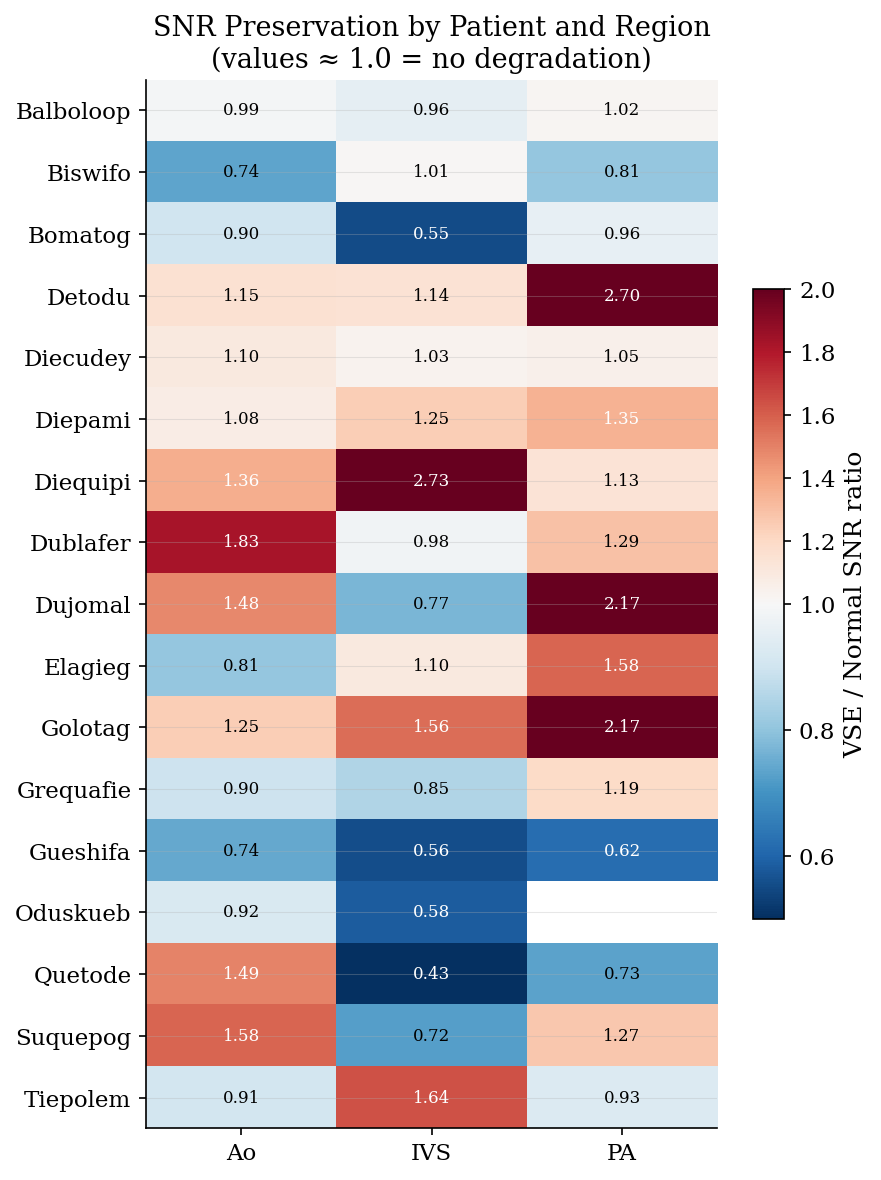

In [174]:
snr_heatmap_data = (
    snr_pivot.reset_index()
    .query("region != 'Background'")
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = snr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(snr_heatmap_data.columns)))
ax.set_xticklabels(snr_heatmap_data.columns)
ax.set_yticks(range(len(snr_heatmap_data.index)))
ax.set_yticklabels(snr_heatmap_data.index)

for i in range(len(snr_heatmap_data.index)):
    for j in range(len(snr_heatmap_data.columns)):
        val = snr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="VSE / Normal SNR ratio")
ax.set_title("SNR Preservation by Patient and Region\n(values ≈ 1.0 = no degradation)", fontsize=13)
fig.tight_layout()
plt.show()